In [27]:
import sys
sys.path.append("../../src")
from common_imports import *
from kibble_zurek import state
from kibble_zurek import sigma_general as sigmax
from kibble_zurek import P_n as Px
from time_evolved_z_correlators import sigma_general as sigmaz
from time_evolved_z_correlators import P_n as Pz
from joblib import Parallel, delayed
import numpy as np
import adiabatic_approx_func as adprox
import kibble_zurek as kz

In [28]:
def defect_exact(n,state):
    return 1/2- Px(n,state)
def defect_approx(n,tau):
    return 1/2 - adprox.P_n(n,tau)

def compute_exact(j, st):
    return j, [
        defect_exact(n, st)
        for n in tqdm(ns, leave=False, desc=f"n (state {j})")
    ]
def compute_approx(j, tau):
    return j, [defect_approx(n,tau) for n in tqdm(ns,leave=False,desc=f"n approx (state {j})")]

In [103]:
N_tau = 50
L = 50
#Condition is tau>>N^2/2Pi^3

tau_ad = 6*(L*L/2/pi/pi/pi)
taus = np.logspace(-2,np.log10(tau_ad),N_tau)

print(tau_ad)

241.8865082489962


In [104]:

states = Parallel(n_jobs=-1)(
    delayed(state)(L, tau, tau) for tau in taus
)



In [105]:
dat = []
for s in states:
    dat.append(Px(12,s))
dat= array(dat)

dat2 = []
for s in states:
    dat2.append(Px(2,s))
dat2= array(dat2)

(0.12, 40.314418041499366)

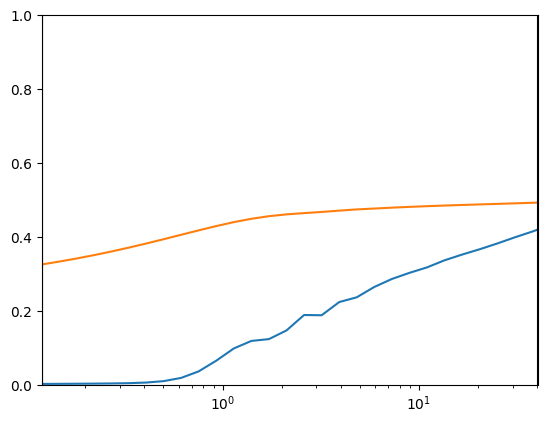

In [106]:
plot(taus,dat)
plot(taus,dat2)
plt.vlines(tau_ad/6,0,1,"k")
plt.vlines(6/(L),0,1,"k")
xscale("log")
#loglog()
ylim(0,1)
xlim(6/L,tau_ad/6)